In [18]:
import pandas as pd

base = pd.read_csv("/content/drive/MyDrive/DO_AN_DS_KI_1_NAM_3/DS201/NLe/KG-building/test_result/transformer_only/test_predictions.csv")
kge  = pd.read_csv("/content/drive/MyDrive/DO_AN_DS_KI_1_NAM_3/DS201/NLe/KG-building/test_result/transformer_kge/test_predictions.csv")

# đảm bảo cùng thứ tự
base = base.sort_values("qa_id").reset_index(drop=True)
kge  = kge.sort_values("qa_id").reset_index(drop=True)

assert all(base.qa_id == kge.qa_id)

In [7]:
!pip install sacrebleu rouge_score bert_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.2 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b210cfd49dd4060c5f0a3ae7dedad120968d8021ea9cd119c1f7e32364358b6a
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [19]:
from sacrebleu.metrics import BLEU

bleu = BLEU(
    smooth_method="exp",
    effective_order=True)

def sentence_bleu(preds, refs):
    scores = []
    for p, r in zip(preds, refs):
        s = bleu.sentence_score(p, [r]).score
        scores.append(s)
    return scores

base["bleu"] = sentence_bleu(base.prediction, base.ground_truth)
kge["bleu"]  = sentence_bleu(kge.prediction,  kge.ground_truth)

In [20]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def sentence_rouge(preds, refs):
    scores = []
    for p, r in zip(preds, refs):
        s = scorer.score(r, p)["rougeL"].fmeasure
        scores.append(s * 100)
    return scores

base["rougeL"] = sentence_rouge(base.prediction, base.ground_truth)
kge["rougeL"]  = sentence_rouge(kge.prediction,  kge.ground_truth)

In [21]:
from bert_score import score as bertscore_score
import numpy as np

def bert_score_sentence(
    predictions,
    ground_truths,
    model_type='xlm-roberta-base'
):
    """
    Compute sentence-level BERTScore (P, R, F1) for each sample
    Returns:
        dict with keys 'precision', 'recall', 'f1'
        values are numpy arrays (scaled to 0-100)
    """
    P, R, F1 = bertscore_score(
        predictions,
        ground_truths,
        model_type=model_type,
        num_layers=9,
        verbose=False,
        rescale_with_baseline=False,
        lang=None
    )

    return {
        'precision': P.cpu().numpy() * 100,
        'recall': R.cpu().numpy() * 100,
        'f1': F1.cpu().numpy() * 100
    }
base_bs = bert_score_sentence(base.prediction.tolist(),
                              base.ground_truth.tolist())

kge_bs  = bert_score_sentence(kge.prediction.tolist(),
                              kge.ground_truth.tolist())

base["bertscore_f1"] = base_bs["f1"]
kge["bertscore_f1"]  = kge_bs["f1"]

In [22]:
import numpy as np
from tqdm import trange

def bootstrap_test(a, b, n_bootstrap=10000):
    diffs = []
    n = len(a)

    for _ in trange(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        diff = np.mean(np.array(b)[idx]) - np.mean(np.array(a)[idx])
        diffs.append(diff)

    diffs = np.array(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p_value = np.mean(diffs <= 0)

    return diffs.mean(), (ci_low, ci_high), p_value

In [23]:
mean_diff, ci, p = bootstrap_test(base.bleu, kge.bleu)
print("/nBLEU Δ:", mean_diff, "CI:", ci, "p:", p)

100%|██████████| 10000/10000 [00:00<00:00, 11199.26it/s]

/nBLEU Δ: 24.17882362810189 CI: (np.float64(22.210985362000397), np.float64(26.19796190683518)) p: 0.0


In [24]:
mean_diff, ci, p = bootstrap_test(base.rougeL, kge.rougeL)
print("ROUGE-L Δ:", mean_diff, "CI:", ci, "p:", p)

100%|██████████| 10000/10000 [00:00<00:00, 11200.37it/s]

ROUGE-L Δ: 26.213249252850556 CI: (np.float64(24.174291981661195), np.float64(28.217783849327148)) p: 0.0


In [25]:
from scipy.stats import ttest_rel, wilcoxon

t_stat, p_t = ttest_rel(kge.bertscore_f1, base.bertscore_f1)
w_stat, p_w = wilcoxon(kge.bertscore_f1, base.bertscore_f1)

print("BERTScore t-test p:", p_t)
print("BERTScore Wilcoxon p:", p_w)

BERTScore t-test p: 2.0031460468649855e-145
BERTScore Wilcoxon p: 8.816474989611844e-98


In [26]:
# 1. align check
assert (base.qa_id == kge.qa_id).all()

# 2. GT giống nhau
assert (base.ground_truth == kge.ground_truth).all()

# 3. mean check
print("BLEU base / kge:", base.bleu.mean(), kge.bleu.mean())
print("ROUGE base / kge:", base.rougeL.mean(), kge.rougeL.mean())
print("BERTScore base / kge:",
      base.bertscore_f1.mean(), kge.bertscore_f1.mean())

BLEU base / kge: 4.680173166706977 28.853015996404594
ROUGE base / kge: 25.31417643941417 51.527470604982504
BERTScore base / kge: 80.589676 89.47311


In [27]:
THRESH = 50.0

bad_rows = kge[
    (kge["bleu"] < THRESH) |
    (kge["rougeL"] < THRESH) |
    (kge["bertscore_f1"] < THRESH)
]

print(f"Number of bad samples: {len(bad_rows)}")

for _, r in bad_rows.iterrows():
    print("=" * 80)
    print("qa_id:", r.qa_id)
    print("Question:", r.question)
    print("Ground truth:", r.ground_truth)
    print("Prediction:", r.prediction)
    print(f"BLEU: {r.bleu:.2f} | ROUGE-L: {r.rougeL:.2f} | BERTScore: {r.bertscore_f1:.2f}")

Number of bad samples: 492
qa_id: body-part_124
Question: Tại sao Testosterone và dihydrotestosterone (DHT) được xem là những androgen duy nhất?
Ground truth: Testosterone và dihydrotestosterone (DHT) là những androgen duy nhất vì chúng là những hormone andro
Prediction: Testosterone và chất chuyển hóa có hoạt tính androgen trực tiếp là những hormone duy nhất gây ra
BLEU: 12.15 | ROUGE-L: 34.04 | BERTScore: 90.13
qa_id: body-part_1878
Question: Đâu là tình trạng viêm mủ của các nang lông mi bị nhiễm trùng; các tuyến bã nhờn xung quanh bờ mi?
Ground truth: Tình trạng viêm mủ của các nang lông mi bị nhiễm trùng; các tuyến bã nhờn xung quanh bờ mi gọi là mụ
Prediction: Viêm mủ của các nang lông mi bị nhiễm trùng, chúng có thể gây ra viêm mủ ở vùng mi mắt và nơi
BLEU: 35.73 | ROUGE-L: 55.07 | BERTScore: 91.03
qa_id: body-part_1997
Question: Trong trường hợp nào thì hội chứng Turner phải kết hợp điều trị nội khoa với phẫu thuật?
Ground truth: Hội chứng Turner phải kết hợp điều trị nội khoa 

In [31]:
import json
import os

def export_to_json(data, filename):
    """
    Export Python data to a JSON file.

    Args:
        data (dict | list): Data to be saved (must be JSON serializable).
        filename (str): Path to the output JSON file.
    """
    # Validate filename
    if not isinstance(filename, str) or not filename.strip():
        raise ValueError("Filename must be a non-empty string.")

    # Ensure directory exists
    os.makedirs(os.path.dirname(filename) or ".", exist_ok=True)

    try:
        with open(filename, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=4)
            # ensure_ascii=False keeps Unicode characters readable
            # indent=4 makes the file human-readable
        print(f"✅ Data successfully exported to '{filename}'")
    except (TypeError, ValueError) as e:
        print(f"Data is not JSON serializable: {e}")
    except OSError as e:
        print(f"File write error: {e}")

export_to_json(
    bad_rows.set_index("qa_id").to_dict(orient="index"),
    "/content/drive/MyDrive/DO_AN_DS_KI_1_NAM_3/DS201/NLe/KG-building/test_result/bad_results.json"
)


✅ Data successfully exported to '/content/drive/MyDrive/DO_AN_DS_KI_1_NAM_3/DS201/NLe/KG-building/test_result/bad_results.json'


In [28]:
very_bad = kge[
    (kge["bleu"] < THRESH) &
    (kge["rougeL"] < THRESH) &
    (kge["bertscore_f1"] < THRESH)
]

print(f"Very bad samples: {len(very_bad)}")

for _, r in very_bad.iterrows():
    print("=" * 80)
    print("qa_id:", r.qa_id)
    print("Question:", r.question)
    print("GT:", r.ground_truth)
    print("Pred:", r.prediction)
    print(f"BLEU={r.bleu:.2f}, ROUGE={r.rougeL:.2f}, BERT={r.bertscore_f1:.2f}")

Very bad samples: 0


In [29]:
bad_kge = kge[
    (kge["bleu"] < THRESH) &
    (kge["rougeL"] < THRESH)
]

for idx, r in bad_kge.iterrows():
    print("=" * 80)
    print("qa_id:", r.qa_id)
    print("Q:", r.question)
    print("GT:", r.ground_truth)
    print("Base:", base.loc[idx].prediction)
    print("KGE :", kge.loc[idx].prediction)
    print(
        f"Base BLEU={base.loc[idx].bleu:.2f}, "
        f"KGE BLEU={kge.loc[idx].bleu:.2f}"
    )

qa_id: body-part_124
Q: Tại sao Testosterone và dihydrotestosterone (DHT) được xem là những androgen duy nhất?
GT: Testosterone và dihydrotestosterone (DHT) là những androgen duy nhất vì chúng là những hormone andro
Base: *. - Estrogen (DHT). - Testosterone (DHT). - Testosterone (DHT). - Testosterone (DHT). - Testosterone (DHT). - Testosterone (DHT)
KGE : Testosterone và chất chuyển hóa có hoạt tính androgen trực tiếp là những hormone duy nhất gây ra
Base BLEU=3.99, KGE BLEU=12.15
qa_id: body-part_1997
Q: Trong trường hợp nào thì hội chứng Turner phải kết hợp điều trị nội khoa với phẫu thuật?
GT: Hội chứng Turner phải kết hợp điều trị nội khoa với phẫu thuật trong một số trường hợp đặc biệt.
Base: *+_ Hội chứng KlinefelterZ gây bệnh và điều trị. - Hội chứng Klinefelter[] - Hội chứng Turner! hội chứng Turner> - Hội chứng Klinefelterjlinefelter Hội chứng Turner&
KGE : Khi trẻ dậy thì muộn hoặc khi nồng độ testosterone quá thấp.
Base BLEU=5.17, KGE BLEU=1.67
qa_id: body-part_2635
Q: Tại s

In [40]:
import json
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def check_errors(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    report = []

    # Các từ kết thúc lửng lơ gây lỗi Truncated
    stop_words_tail = r'( cho| để| là| và| từ| với| của| tại| thì| g| mg| ml)$'

    for key, item in data.items():
        pred = item.get('prediction', '').strip()
        gt = item.get('ground_truth', '').strip()
        q = item.get('question', '').strip()
        entities = [e.strip().lower() for e in item.get('entities', '').split(',')]

        found_errors = []

        # 1. Kiểm tra Lỗi bị cắt cụt (Truncated)
        if re.search(stop_words_tail, pred, re.IGNORECASE) or (len(pred) > 0 and pred[-1] not in ['.', '!', '?', '}', ')', '"']):
            found_errors.append("Truncated Output")

        # 2. Kiểm tra Lỗi lặp lại câu hỏi (Restating Question)
        # Sử dụng Cosine Similarity để xem Prediction có quá giống Question không
        tfidf = TfidfVectorizer().fit_transform([q, pred])
        cos_sim = cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]
        if cos_sim > 0.8: # Giống trên 80% từ vựng câu hỏi
            found_errors.append("Restating Question")

        # 3. Kiểm tra Lỗi trả lời lạc đề (Irrelevant Response)
        # Nếu Prediction cực kỳ khác Ground Truth (Cosine Sim < 0.2)
        tfidf_gt = TfidfVectorizer().fit_transform([gt, pred])
        cos_sim_gt = cosine_similarity(tfidf_gt[0:1], tfidf_gt[1:2])[0][0]
        if cos_sim_gt < 0.15:
            found_errors.append("Irrelevant Response")

        # 4. Kiểm tra Lỗi thiếu thực thể (Missing Specific Entity)
        missing = [e for e in entities if e not in pred.lower()]
        if len(missing) > len(entities) / 2 and len(entities) > 0:
            found_errors.append(f"Missing Entities ({len(missing)} items)")
    return report

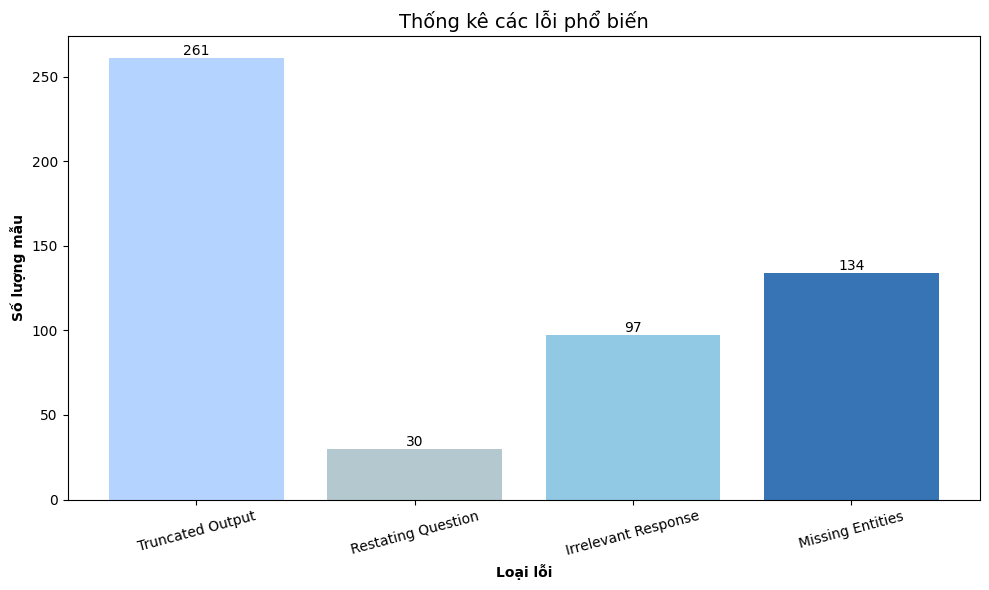

Kết quả thống kê: {'Truncated Output': 261, 'Restating Question': 30, 'Irrelevant Response': 97, 'Missing Entities': 134}


In [49]:
import json
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def analyze_and_plot(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Dictionary để đếm số lượng từng loại lỗi
    error_counts = {
        "Truncated Output": 0,
        "Restating Question": 0,
        "Irrelevant Response": 0,
        "Missing Entities": 0,
        # "Hallucination (Low Score)": 0
    }

    # Danh sách các từ khiến câu bị lửng lơ (tiếng Việt)
    stop_words_tail = r'( cho| để| là| và| từ| với| của| tại| g| mg| ml| tìm| và)$'

    for key, item in data.items():
        pred = str(item.get('prediction', '')).strip().lower()
        q = str(item.get('question', '')).strip().lower()
        gt = str(item.get('ground_truth', '')).strip().lower()
        entities = [e.strip().lower() for e in item.get('entities', '').split(',')]
        bleu = item.get('bleu', 100)

        # 1. Kiểm tra Lỗi bị cắt cụt (Truncated)
        # Nếu kết thúc bằng từ nối HOẶC không có dấu kết câu (và câu đủ dài)
        if re.search(stop_words_tail, pred) or (len(pred) > 20 and pred[-1] not in ['.', '!', '?', '}', ')']):
            error_counts["Truncated Output"] += 1

        # 2. Kiểm tra Lỗi trả lời lạc đề (Irrelevant Response)
        # Sử dụng Tfidf để so sánh Pred và GT, nếu quá khác biệt (< 0.1)
        if pred and gt:
            try:
                tfidf = TfidfVectorizer().fit_transform([gt, pred])
                sim = cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]
                if sim < 0.1:
                    error_counts["Irrelevant Response"] += 1
            except:
                pass

        # 3. Kiểm tra Lỗi thiếu thực thể (Missing Entities)
        if entities and entities[0] != '':
            missing = [e for e in entities if e not in pred]
            if len(missing) > len(entities) / 2:
                error_counts["Missing Entities"] += 1

        # # 4. Kiểm tra Hallucination (Dựa trên BLEU thấp của file)
        # if bleu < 5: # Ngưỡng BLEU rất thấp thường là sai kiến thức hoàn toàn
        #     error_counts["Hallucination (Low Score)"] += 1

        # 5. Kiểm tra Lỗi lặp lại câu hỏi (Restating Question)
        tfidf = TfidfVectorizer().fit_transform([q, pred])
        cos_sim = cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]
        if cos_sim > 0.8: # Giống trên 80% từ vựng câu hỏi
            error_counts["Restating Question"] += 1

    # --- PHẦN VẼ BIỂU ĐỒ ---
    labels = list(error_counts.keys())
    values = list(error_counts.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, values, color=['#B4D4FF','#B3C8CF','#91C8E4','#3674B5', '#3FA2F6'])

    plt.xlabel('Loại lỗi', fontweight='bold')
    plt.ylabel('Số lượng mẫu', fontweight='bold')
    plt.title('Thống kê các lỗi phổ biến', fontsize=14)
    plt.xticks(rotation=15)

    # Thêm số liệu trên đầu mỗi cột
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return error_counts

# Chạy code
stats = analyze_and_plot('/content/drive/MyDrive/DO_AN_DS_KI_1_NAM_3/DS201/NLe/KG-building/test_result/bad_results.json')
print("Kết quả thống kê:", stats)